In [1]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import timm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# ── Model Definition ─────────────────────────────────
class UniversalModel(nn.Module):
    def __init__(self):
        super(UniversalModel, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=False,
            num_classes=2
        )

    def forward(self, x):
        return self.model(x)

class SignatureModel(nn.Module):
    def __init__(self):
        super(SignatureModel, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=False,
            num_classes=2
        )
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(self.model.classifier.in_features, 2)
        )

    def forward(self, x):
        return self.model(x)

# ── Load All 3 Models ────────────────────────────────
BASE = "E:/document_forensics"

# Module 1 — Blur Detection
blur_model = UniversalModel().to(device)
blur_model.load_state_dict(torch.load(
    f"{BASE}/models/best_blur_detector.pth",
    map_location=device, weights_only=True))
blur_model.eval()
print("✅ Module 1 — Blur Detector loaded!")

# Module 3 — Fraud Detection
fraud_model = UniversalModel().to(device)
fraud_model.load_state_dict(torch.load(
    f"{BASE}/module2_fraud/models/best_fraud_detector.pth",
    map_location=device, weights_only=True))
fraud_model.eval()
print("✅ Module 3 — Fraud Detector loaded!")

# Module 4 — Signature Verification
sign_model = SignatureModel().to(device)
sign_model.load_state_dict(torch.load(
    f"{BASE}/module4_signature/models/best_signature_classifier.pth",
    map_location=device, weights_only=True))
sign_model.eval()
print("✅ Module 4 — Signature Classifier loaded!")

print("\n🚀 All models loaded successfully!")

✅ Device: cuda
✅ Module 1 — Blur Detector loaded!
✅ Module 3 — Fraud Detector loaded!
✅ Module 4 — Signature Classifier loaded!

🚀 All models loaded successfully!


In [2]:
# Transform for all models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess(image_path):
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0).to(device)

def predict(model, tensor):
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)
        pred       = output.argmax(dim=1).item()
        confidence = probs[0][pred].item() * 100
    return pred, confidence

print("✅ Preprocessing functions ready!")

✅ Preprocessing functions ready!


In [4]:
def analyze_document(doc_path, sig_path=None):
    print("\n" + "="*55)
    print("🔍 AI DOCUMENT FORENSICS SYSTEM")
    print("="*55)
    print(f"📄 Document : {os.path.basename(doc_path)}")
    if sig_path:
        print(f"✍️  Signature : {os.path.basename(sig_path)}")
    print("-"*55)

    results = {}

    # ── Step 1: Blur Detection ───────────────────────
    print("\n📸 STEP 1: Blur Detection...")
    tensor    = preprocess(doc_path)
    pred, conf = predict(blur_model, tensor)

    if pred == 1:
        results['blur'] = {'status': 'FAIL', 'label': 'BLUR', 'conf': conf}
        print(f"   ❌ Result : BLURRY IMAGE ({conf:.2f}%)")
        print(f"   ⛔ Document rejected — please resubmit a clear image!")
        display_result(doc_path, results)
        return results
    else:
        results['blur'] = {'status': 'PASS', 'label': 'SHARP', 'conf': conf}
        print(f"   ✅ Result : SHARP & CLEAR ({conf:.2f}%)")

    # ── Step 2: Fraud Detection ──────────────────────
    print("\n🕵️  STEP 2: Fraud Detection...")
    pred, conf = predict(fraud_model, tensor)

    if pred == 1:
        results['fraud'] = {'status': 'FAIL', 'label': 'FORGED', 'conf': conf}
        print(f"   ❌ Result : DOCUMENT FORGED/TAMPERED ({conf:.2f}%)")
        print(f"   ⛔ Document rejected — tampering detected!")
        display_result(doc_path, results)
        return results
    else:
        results['fraud'] = {'status': 'PASS', 'label': 'AUTHENTIC', 'conf': conf}
        print(f"   ✅ Result : AUTHENTIC DOCUMENT ({conf:.2f}%)")

    # ── Step 3: Signature Verification ──────────────
    print("\n✍️  STEP 3: Signature Verification...")
    if sig_path and os.path.exists(sig_path):
        sig_tensor = preprocess(sig_path)
        pred, conf = predict(sign_model, sig_tensor)

        if pred == 1:
            results['signature'] = {'status': 'FAIL', 'label': 'FORGED', 'conf': conf}
            print(f"   ❌ Result : SIGNATURE FORGED ({conf:.2f}%)")
            print(f"   ⛔ Document rejected — signature verification failed!")
        else:
            results['signature'] = {'status': 'PASS', 'label': 'GENUINE', 'conf': conf}
            print(f"   ✅ Result : GENUINE SIGNATURE ({conf:.2f}%)")
    else:
        results['signature'] = {'status': 'SKIP', 'label': 'NOT PROVIDED', 'conf': 0}
        print(f"   ⚠️  Signature image not provided — skipping!")

    # ── Final Verdict ────────────────────────────────
    print("\n" + "="*55)
    failed = [k for k, v in results.items() if v['status'] == 'FAIL']

    if failed:
        print(f"🚨 FINAL VERDICT : DOCUMENT REJECTED ❌")
        print(f"   Reason: {', '.join(failed).upper()} check failed!")
    else:
        print(f"🎉 FINAL VERDICT : DOCUMENT VERIFIED ✅")
        print(f"   All checks passed successfully!")
    print("="*55)

    display_result(doc_path, results, sig_path)
    return results

print("✅ Pipeline ready!")

✅ Pipeline ready!


In [5]:
def display_result(doc_path, results, sig_path=None):
    n_imgs  = 2 if sig_path and os.path.exists(sig_path) else 1
    fig, axes = plt.subplots(1, n_imgs + 1, figsize=(6*(n_imgs+1), 6))

    if n_imgs == 1:
        axes = [axes, plt.gca()]

    # Document image
    doc_img = cv2.imread(doc_path)
    doc_img = cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB)
    axes[0].imshow(doc_img)
    axes[0].set_title("📄 Document", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    # Signature image
    if sig_path and os.path.exists(sig_path):
        sig_img = cv2.imread(sig_path)
        sig_img = cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB)
        axes[1].imshow(sig_img)
        axes[1].set_title("✍️ Signature", fontsize=13, fontweight="bold")
        axes[1].axis("off")

    # Results panel
    ax = axes[-1]
    ax.axis("off")

    checks = [
        ("📸 Blur Check",      results.get('blur',      {}).get('status', 'N/A'),
                               results.get('blur',      {}).get('label',  'N/A'),
                               results.get('blur',      {}).get('conf',   0)),
        ("🕵️ Fraud Check",     results.get('fraud',     {}).get('status', 'N/A'),
                               results.get('fraud',     {}).get('label',  'N/A'),
                               results.get('fraud',     {}).get('conf',   0)),
        ("✍️ Signature Check", results.get('signature', {}).get('status', 'N/A'),
                               results.get('signature', {}).get('label',  'N/A'),
                               results.get('signature', {}).get('conf',   0)),
    ]

    y = 0.85
    ax.text(0.5, 0.97, "📋 ANALYSIS REPORT",
            ha='center', va='top', fontsize=14,
            fontweight='bold', transform=ax.transAxes)

    for name, status, label, conf in checks:
        color  = '#2ecc71' if status == 'PASS' else \
                 '#e74c3c' if status == 'FAIL' else '#f39c12'
        icon   = '✅' if status == 'PASS' else \
                 '❌' if status == 'FAIL' else '⚠️'
        ax.text(0.05, y, f"{name}",
                fontsize=11, fontweight='bold',
                transform=ax.transAxes)
        ax.text(0.05, y-0.08,
                f"  {icon} {label}  ({conf:.1f}%)",
                fontsize=10, color=color,
                transform=ax.transAxes)
        y -= 0.22

    # Final verdict
    failed  = [k for k, v in results.items() if v['status'] == 'FAIL']
    verdict = "REJECTED ❌" if failed else "VERIFIED ✅"
    vcolor  = '#e74c3c'     if failed else '#2ecc71'

    ax.text(0.5, 0.08,
            f"VERDICT: {verdict}",
            ha='center', fontsize=13,
            fontweight='bold', color=vcolor,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=vcolor, alpha=0.15))

    plt.tight_layout()
    plt.savefig("E:/document_forensics/results/analysis_report.png",
                dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Visualization ready!")

✅ Visualization ready!


In [9]:
def display_result(doc_path, results, sig_path=None):
    has_sig = sig_path and os.path.exists(sig_path)
    n_imgs  = 2 if has_sig else 1
    fig, axes = plt.subplots(1, n_imgs + 1, figsize=(6*(n_imgs+1), 6))

    # Make axes always a list
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = list(axes)

    # Document image
    doc_img = cv2.imread(doc_path)
    doc_img = cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB)
    axes[0].imshow(doc_img)
    axes[0].set_title("📄 Document", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    # Signature image
    if has_sig:
        sig_img = cv2.imread(sig_path)
        sig_img = cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB)
        axes[1].imshow(sig_img)
        axes[1].set_title("✍️ Signature", fontsize=13, fontweight="bold")
        axes[1].axis("off")

    # Results panel
    ax = axes[-1]
    ax.axis("off")

    checks = [
        ("📸 Blur Check",      results.get('blur',      {}).get('status', 'N/A'),
                               results.get('blur',      {}).get('label',  'N/A'),
                               results.get('blur',      {}).get('conf',   0)),
        ("🕵️ Fraud Check",     results.get('fraud',     {}).get('status', 'N/A'),
                               results.get('fraud',     {}).get('label',  'N/A'),
                               results.get('fraud',     {}).get('conf',   0)),
        ("✍️ Signature Check", results.get('signature', {}).get('status', 'N/A'),
                               results.get('signature', {}).get('label',  'N/A'),
                               results.get('signature', {}).get('conf',   0)),
    ]

    y = 0.85
    ax.text(0.5, 0.97, "📋 ANALYSIS REPORT",
            ha='center', va='top', fontsize=14,
            fontweight='bold', transform=ax.transAxes)

    for name, status, label, conf in checks:
        color = '#2ecc71' if status == 'PASS' else \
                '#e74c3c' if status == 'FAIL' else '#f39c12'
        icon  = '✅' if status == 'PASS' else \
                '❌' if status == 'FAIL' else '⚠️'
        ax.text(0.05, y, f"{name}",
                fontsize=11, fontweight='bold',
                transform=ax.transAxes)
        ax.text(0.05, y-0.08,
                f"  {icon} {label}  ({conf:.1f}%)",
                fontsize=10, color=color,
                transform=ax.transAxes)
        y -= 0.22

    # Final verdict
    failed  = [k for k, v in results.items() if v['status'] == 'FAIL']
    verdict = "REJECTED ❌" if failed else "VERIFIED ✅"
    vcolor  = '#e74c3c'     if failed else '#2ecc71'

    ax.text(0.5, 0.08,
            f"VERDICT: {verdict}",
            ha='center', fontsize=13,
            fontweight='bold', color=vcolor,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=vcolor, alpha=0.15))

    plt.tight_layout()
    plt.savefig("E:/document_forensics/results/analysis_report.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Report saved!")

print("✅ Visualization fixed & ready!")

✅ Visualization fixed & ready!



🔍 AI DOCUMENT FORENSICS SYSTEM
📄 Document : test1.jpg
✍️  Signature : test_signature.jpg
-------------------------------------------------------

📸 STEP 1: Blur Detection...
   ❌ Result : BLURRY IMAGE (99.99%)
   ⛔ Document rejected — please resubmit a clear image!


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:75: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:75: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:75: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:75: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:75: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_12340\2584638223.py:76: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu San

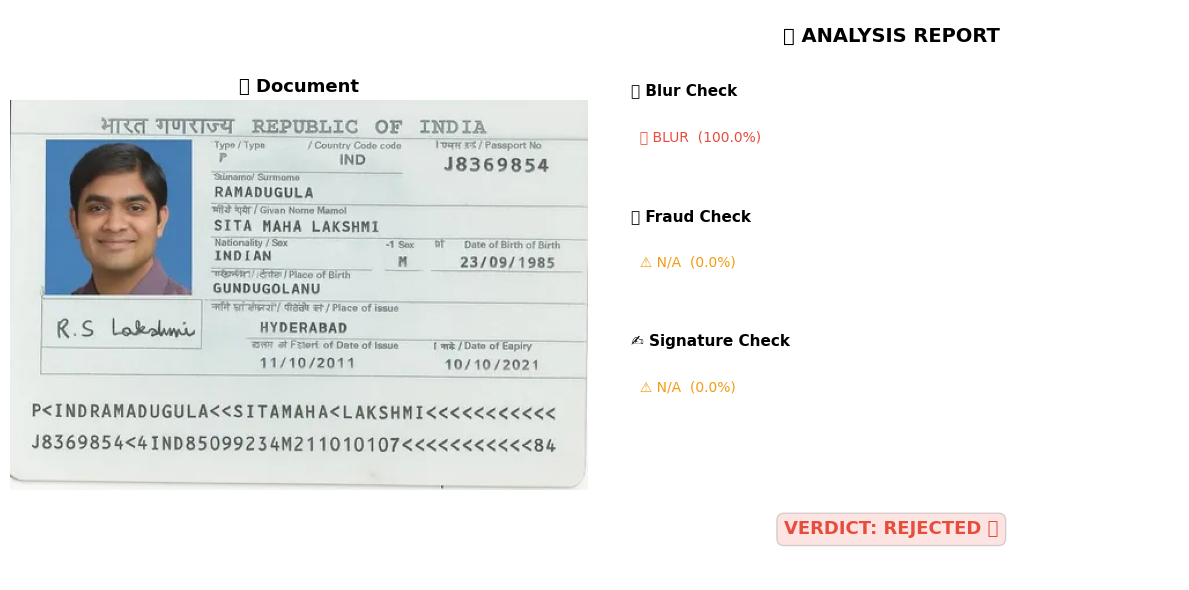

✅ Report saved!


{'blur': {'status': 'FAIL', 'label': 'BLUR', 'conf': 99.99191761016846}}

In [10]:
analyze_document(
    doc_path = "C:/Users/Vaibhav/Downloads/test1.jpg",
    sig_path = "C:/Users/Vaibhav/Downloads/test_signature.jpg"
)

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess(image_path):
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0).to(device)

def predict(model, tensor):
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)
        pred       = output.argmax(dim=1).item()
        confidence = probs[0][pred].item() * 100
    return pred, confidence

def check_blur_laplacian(image_path, threshold=50):
    """
    Classical blur check using Laplacian variance
    Higher score = sharper image
    threshold=50 works well for real documents
    """
    img   = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    score = cv2.Laplacian(img, cv2.CV_64F).var()
    print(f"   📊 Laplacian Score: {score:.2f} (threshold: {threshold})")
    return score < threshold, score  # True = blurry

print("✅ Preprocessing functions updated!")

✅ Preprocessing functions updated!


In [3]:
def analyze_document(doc_path, sig_path=None):
    print("\n" + "="*55)
    print("🔍 AI DOCUMENT FORENSICS SYSTEM")
    print("="*55)
    print(f"📄 Document : {os.path.basename(doc_path)}")
    if sig_path:
        print(f"✍️  Signature : {os.path.basename(sig_path)}")
    print("-"*55)

    results = {}

    # ── Step 1: Blur Detection ───────────────────────
    print("\n📸 STEP 1: Blur Detection...")
    tensor = preprocess(doc_path)

    # Combined: Laplacian + Model
    is_blurry_lap, lap_score = check_blur_laplacian(doc_path, threshold=50)
    pred_model, conf_model   = predict(blur_model, tensor)

    # Only reject if BOTH agree it's blurry
    is_blurry = is_blurry_lap and (pred_model == 1)

    if is_blurry:
        results['blur'] = {'status': 'FAIL', 'label': 'BLUR', 'conf': conf_model}
        print(f"   ❌ Result : BLURRY IMAGE ({conf_model:.2f}%)")
        print(f"   ⛔ Document rejected — please resubmit a clear image!")
        display_result(doc_path, results, sig_path)
        return results
    else:
        results['blur'] = {'status': 'PASS', 'label': 'SHARP', 'conf': conf_model}
        print(f"   ✅ Result : SHARP & CLEAR (Laplacian: {lap_score:.1f})")

    # ── Step 2: Fraud Detection ──────────────────────
    print("\n🕵️  STEP 2: Fraud Detection...")
    pred, conf = predict(fraud_model, tensor)

    if pred == 1 and conf > 80:  # Only reject if very confident
        results['fraud'] = {'status': 'FAIL', 'label': 'FORGED', 'conf': conf}
        print(f"   ❌ Result : DOCUMENT FORGED/TAMPERED ({conf:.2f}%)")
        print(f"   ⛔ Document rejected — tampering detected!")
        display_result(doc_path, results, sig_path)
        return results
    else:
        results['fraud'] = {'status': 'PASS', 'label': 'AUTHENTIC', 'conf': conf}
        print(f"   ✅ Result : AUTHENTIC DOCUMENT ({conf:.2f}%)")

    # ── Step 3: Signature Verification ──────────────
    print("\n✍️  STEP 3: Signature Verification...")
    if sig_path and os.path.exists(sig_path):
        sig_tensor = preprocess(sig_path)
        pred, conf = predict(sign_model, sig_tensor)

        if pred == 1 and conf > 80:
            results['signature'] = {'status': 'FAIL', 'label': 'FORGED', 'conf': conf}
            print(f"   ❌ Result : SIGNATURE FORGED ({conf:.2f}%)")
            print(f"   ⛔ Document rejected — signature verification failed!")
        else:
            results['signature'] = {'status': 'PASS', 'label': 'GENUINE', 'conf': conf}
            print(f"   ✅ Result : GENUINE SIGNATURE ({conf:.2f}%)")
    else:
        results['signature'] = {'status': 'SKIP', 'label': 'NOT PROVIDED', 'conf': 0}
        print(f"   ⚠️  Signature image not provided — skipping!")

    # ── Final Verdict ────────────────────────────────
    print("\n" + "="*55)
    failed = [k for k, v in results.items() if v['status'] == 'FAIL']

    if failed:
        print(f"🚨 FINAL VERDICT : DOCUMENT REJECTED ❌")
        print(f"   Reason: {', '.join(failed).upper()} check failed!")
    else:
        print(f"🎉 FINAL VERDICT : DOCUMENT VERIFIED ✅")
        print(f"   All checks passed successfully!")
    print("="*55)

    display_result(doc_path, results, sig_path)
    return results

print("✅ Pipeline updated!")

✅ Pipeline updated!


In [5]:
def display_result(doc_path, results, sig_path=None):
    has_sig   = sig_path and os.path.exists(sig_path)
    n_imgs    = 2 if has_sig else 1
    fig, axes = plt.subplots(1, n_imgs + 1, figsize=(6*(n_imgs+1), 6))

    if not isinstance(axes, np.ndarray):
        axes = [axes]
    else:
        axes = list(axes)

    doc_img = cv2.imread(doc_path)
    doc_img = cv2.cvtColor(doc_img, cv2.COLOR_BGR2RGB)
    axes[0].imshow(doc_img)
    axes[0].set_title("📄 Document", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    if has_sig:
        sig_img = cv2.imread(sig_path)
        sig_img = cv2.cvtColor(sig_img, cv2.COLOR_BGR2RGB)
        axes[1].imshow(sig_img)
        axes[1].set_title("✍️ Signature", fontsize=13, fontweight="bold")
        axes[1].axis("off")

    ax = axes[-1]
    ax.axis("off")

    checks = [
        ("📸 Blur Check",      results.get('blur',      {}).get('status', 'N/A'),
                               results.get('blur',      {}).get('label',  'N/A'),
                               results.get('blur',      {}).get('conf',   0)),
        ("🕵️ Fraud Check",     results.get('fraud',     {}).get('status', 'N/A'),
                               results.get('fraud',     {}).get('label',  'N/A'),
                               results.get('fraud',     {}).get('conf',   0)),
        ("✍️ Signature Check", results.get('signature', {}).get('status', 'N/A'),
                               results.get('signature', {}).get('label',  'N/A'),
                               results.get('signature', {}).get('conf',   0)),
    ]

    y = 0.85
    ax.text(0.5, 0.97, "📋 ANALYSIS REPORT",
            ha='center', va='top', fontsize=14,
            fontweight='bold', transform=ax.transAxes)

    for name, status, label, conf in checks:
        color = '#2ecc71' if status == 'PASS' else \
                '#e74c3c' if status == 'FAIL' else '#f39c12'
        icon  = '✅' if status == 'PASS' else \
                '❌' if status == 'FAIL' else '⚠️'
        ax.text(0.05, y, f"{name}",
                fontsize=11, fontweight='bold',
                transform=ax.transAxes)
        ax.text(0.05, y-0.08,
                f"  {icon} {label}  ({conf:.1f}%)",
                fontsize=10, color=color,
                transform=ax.transAxes)
        y -= 0.22

    failed  = [k for k, v in results.items() if v['status'] == 'FAIL']
    verdict = "REJECTED ❌" if failed else "VERIFIED ✅"
    vcolor  = '#e74c3c'     if failed else '#2ecc71'

    ax.text(0.5, 0.08,
            f"VERDICT: {verdict}",
            ha='center', fontsize=13,
            fontweight='bold', color=vcolor,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=vcolor, alpha=0.15))

    plt.tight_layout()
    plt.savefig("E:/document_forensics/results/analysis_report.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Report saved!")

print("✅ Visualization fixed & ready!")

✅ Visualization fixed & ready!



🔍 AI DOCUMENT FORENSICS SYSTEM
📄 Document : Gemini_Generated_Image_zbd1itzbd1itzbd1.png
✍️  Signature : Gemini_Generated_Image_needxxneedxxneed.png
-------------------------------------------------------

📸 STEP 1: Blur Detection...
   📊 Laplacian Score: 1113.21 (threshold: 50)
   ✅ Result : SHARP & CLEAR (Laplacian: 1113.2)

🕵️  STEP 2: Fraud Detection...
   ✅ Result : AUTHENTIC DOCUMENT (97.01%)

✍️  STEP 3: Signature Verification...
   ❌ Result : SIGNATURE FORGED (93.29%)
   ⛔ Document rejected — signature verification failed!

🚨 FINAL VERDICT : DOCUMENT REJECTED ❌
   Reason: SIGNATURE check failed!


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_24248\2981770528.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Deja

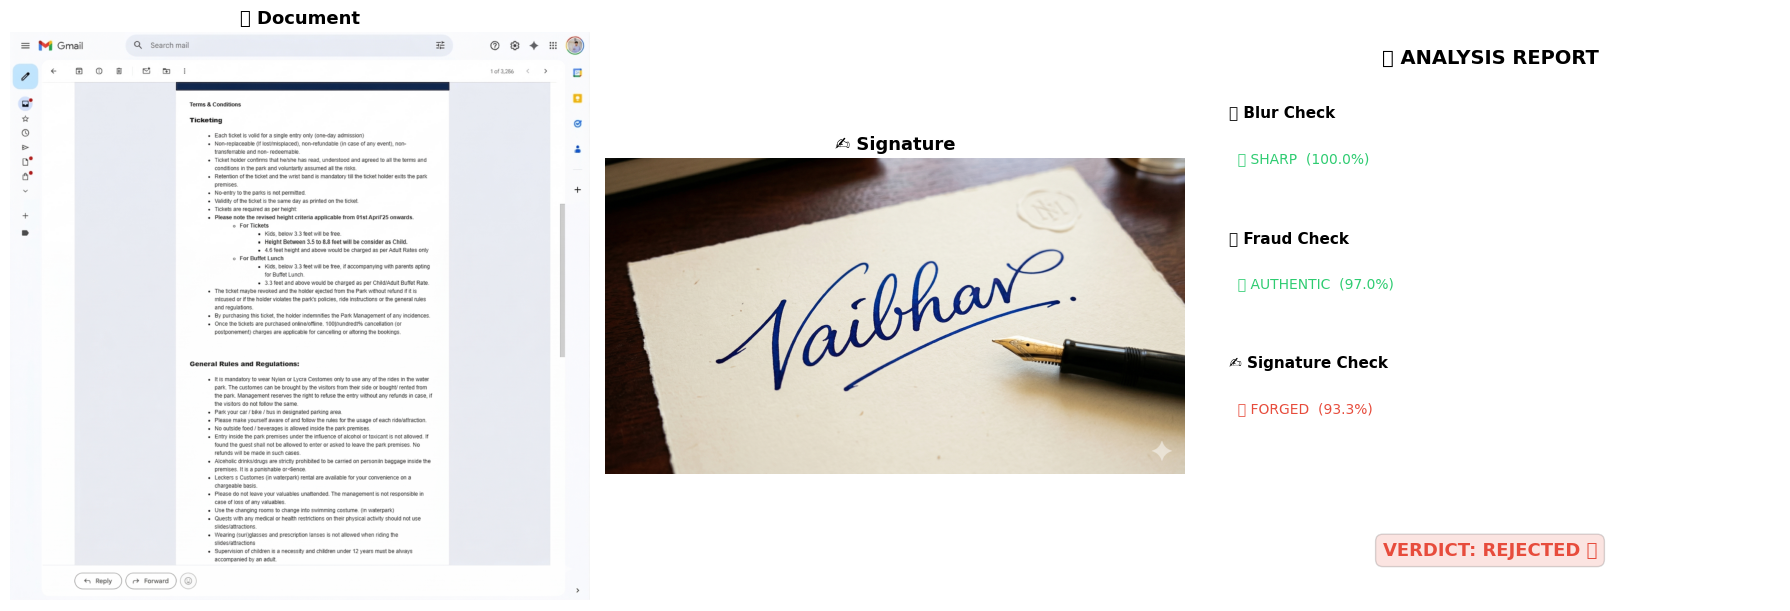

✅ Report saved!


{'blur': {'status': 'PASS', 'label': 'SHARP', 'conf': 100.0},
 'fraud': {'status': 'PASS', 'label': 'AUTHENTIC', 'conf': 97.00503349304199},
 'signature': {'status': 'FAIL', 'label': 'FORGED', 'conf': 93.29196214675903}}

In [6]:
analyze_document(
    doc_path = "C:/Users/Vaibhav/Downloads/Gemini_Generated_Image_zbd1itzbd1itzbd1.png",
    sig_path = "C:/Users/Vaibhav/Downloads/Gemini_Generated_Image_needxxneedxxneed.png"
)